In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)

In [3]:
# load the dataset

df = pd.read_csv("mall_customer_dataset.csv")

print("Dataset Loaded Successfully")
print("\nShape:", df.shape)

df.head()

Dataset Loaded Successfully

Shape: (10100, 12)


,CustomerID,Gender,Age,AnnualIncome,SpendingScore,VisitFrequency,AvgPurchaseValue,SatisfactionScore,ComplaintsCount,LoyaltyPoints,CustomerSegment,ChurnRisk
0,6253,Female,37.0,31.0,22.0,3.0,1113.68,4.6,1,668.0,Budget Shopper,Medium
1,4685,Female,50.0,65.0,47.0,8.0,2224.08,6.1,0,3559.0,Regular Customer,Medium
2,1732,Female,39.0,107.0,81.0,13.0,4000.16,8.1,3,10000.0,Premium Customer,Low
3,4743,Female,40.0,64.0,49.0,10.0,2636.17,7.4,0,5272.0,Regular Customer,Medium
4,4522,Male,52.0,45.0,67.0,11.0,2273.39,7.0,2,5001.0,Regular Customer,Medium


In [4]:
# basic info

print("Dataset Information")
print("="*50)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         10100 non-null  int64  
 1   Gender             10100 non-null  object 
 2   Age                9900 non-null   float64
 3   AnnualIncome       9798 non-null   float64
 4   SpendingScore      9899 non-null   float64
 5   VisitFrequency     9797 non-null   float64
 6   AvgPurchaseValue   10100 non-null  float64
 7   SatisfactionScore  10100 non-null  float64
 8   ComplaintsCount    10100 non-null  int64  
 9   LoyaltyPoints      9698 non-null   float64
 10  CustomerSegment    10100 non-null  object 
 11  ChurnRisk          10100 non-null  object 
dtypes: float64(7), int64(2), object(3)
memory usage: 947.0+ KB


In [5]:
# statistical summary 

df.describe(include='all')

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,VisitFrequency,AvgPurchaseValue,SatisfactionScore,ComplaintsCount,LoyaltyPoints,CustomerSegment,ChurnRisk
count,10100.000000,10100,9900.000000,9798.000000,9899.000000,9797.000000,10100.000000,10100.000000,10100.000000,9698.000000,10100,10100
unique,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,3
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Regular Customer,Medium
freq,NaN,4680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,4044
mean,5005.072277,NaN,38.314141,69.330374,49.924538,7.217924,2653.310412,6.388059,1.407426,4430.254898,NaN,NaN
std,2886.998223,NaN,12.800540,49.889043,26.989338,5.261493,1747.888901,2.320286,1.412407,4668.271220,NaN,NaN
min,1.000000,NaN,-5.000000,15.000000,1.000000,0.000000,296.980000,1.000000,0.000000,0.000000,NaN,NaN
25%,2504.750000,NaN,30.000000,43.000000,22.000000,2.000000,1401.565000,4.500000,0.000000,612.000000,NaN,NaN
50%,5006.500000,NaN,38.000000,62.000000,55.000000,7.000000,2557.725000,6.900000,1.000000,3570.000000,NaN,NaN
75%,7503.250000,NaN,46.000000,91.000000,74.000000,11.000000,3648.975000,8.400000,2.000000,7878.500000,NaN,NaN


In [6]:
# check missing values 

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values
})

missing_df = missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

missing_df

,Column,Missing Values
9,LoyaltyPoints,402
5,VisitFrequency,303
3,AnnualIncome,302
4,SpendingScore,201
2,Age,200
0,CustomerID,0
1,Gender,0
6,AvgPurchaseValue,0
7,SatisfactionScore,0
8,ComplaintsCount,0


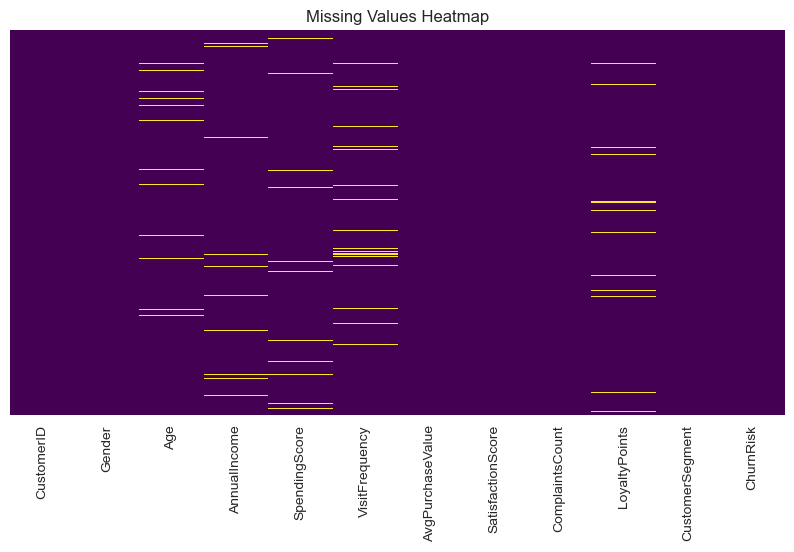

In [ ]:
# visualizing missing values 

plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

In [8]:
# duplicate records 

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 100


In [9]:
# gender value inconsistency 

df["Gender"].value_counts(dropna=False)

Gender
Male      4680
Female    4614
male       136
MALE       136
female     134
F          134
M          133
FEMALE     133
Name: count, dtype: int64

In [10]:
# data types

df.dtypes

CustomerID             int64
Gender                object
Age                  float64
AnnualIncome         float64
SpendingScore        float64
VisitFrequency       float64
AvgPurchaseValue     float64
SatisfactionScore    float64
ComplaintsCount        int64
LoyaltyPoints        float64
CustomerSegment       object
ChurnRisk             object
dtype: object

In [11]:
# numerical columns 

numeric_cols = df.select_dtypes(
    include=np.number
).columns

numeric_cols

Index(['CustomerID', 'Age', 'AnnualIncome', 'SpendingScore', 'VisitFrequency',
       'AvgPurchaseValue', 'SatisfactionScore', 'ComplaintsCount',
       'LoyaltyPoints'],
      dtype='object')

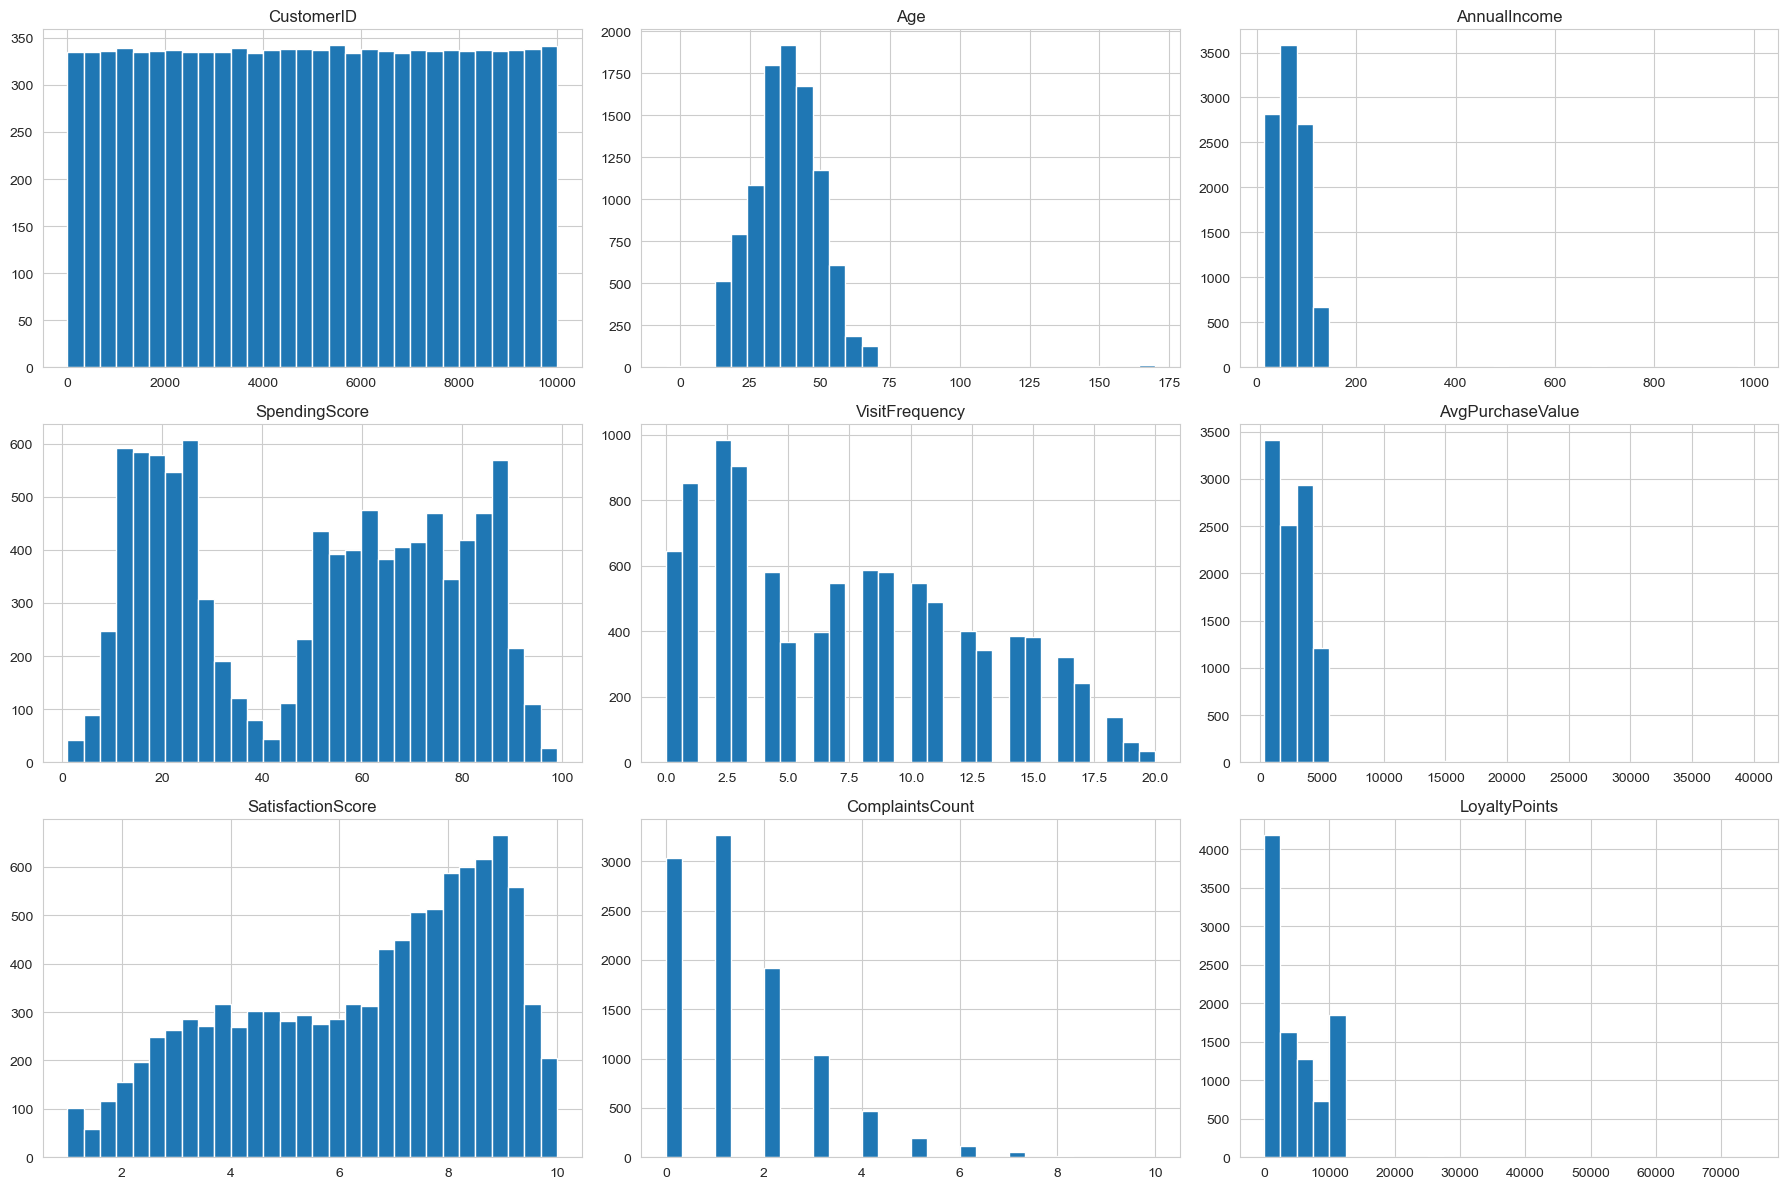

In [12]:
# histograms 

df[numeric_cols].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()
plt.show()

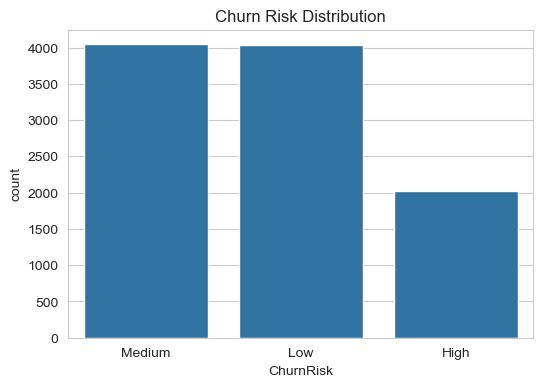

In [13]:
# distribution of churn risk

plt.figure(figsize=(6,4))

sns.countplot(
    x="ChurnRisk",
    data=df
)

plt.title("Churn Risk Distribution")
plt.show()